In [20]:
#Install and import libraries

# Install packages if you need them
#%pip install pandas
#%pip install seaborn
#%pip install scipy

# Import packages
import pandas as pd
import seaborn as sns

from scipy.stats import exponnorm
import numpy as np

In [21]:
# load the raw data into a dataframe
# your path will be different
# remember to add /work/ at the beginning of the string
raw = pd.read_csv('/Users/ethan/Documents/GitHub/ExPsyLing/experiments/masked_prime/data/combined_data.csv')

In [22]:
# make a list of all the columns we want to keep
cols = ['participant_id', 'sender', 'duration', 'prime', 'target', 'condition', 'soa_condition', 'congruence', 'response', 'correct_response']

In [23]:
df = raw[cols]                                                             # make a new dataframe with only the columns in cols
df = df[df['sender'] == 'target']                                          # only keep the "target" rows
df = df[df['condition'] != 'practice']                                     # throw away the practice trials
df.loc[df['target'] == 'BULL', 'correct_response'] = 'n'                   # fix the correct response on "bull"
df['correct'] = (df['response'] == df['correct_response']).astype(int)     # make a new column with 0 or 1 for incorrect / correct
df = df[df['correct'] == 1]                                                # keep only the correct responses   
df = df.rename(columns={'soa_condition': 'soa', 'duration': 'rt'})         # rename the soa and duration columns, just to look nicer

In [24]:
# find average values for the conditions. I did this slightly wrong in class, as I suspected. This is the right way.
df_grouped = df.groupby(['participant_id', 'soa', 'congruence'])['rt'].mean().reset_index()

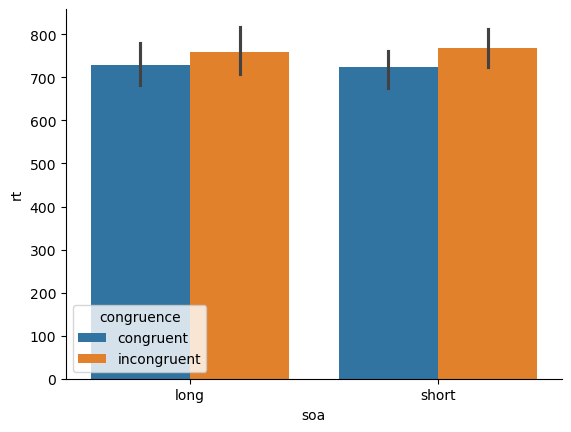

In [25]:
# make barplot of the data.
sns.barplot(data=df_grouped, x='soa', y='rt', hue='congruence')            # make a barplot
sns.despine()                                                              # get rid of the lines around the top and bottom - looks much nicer!

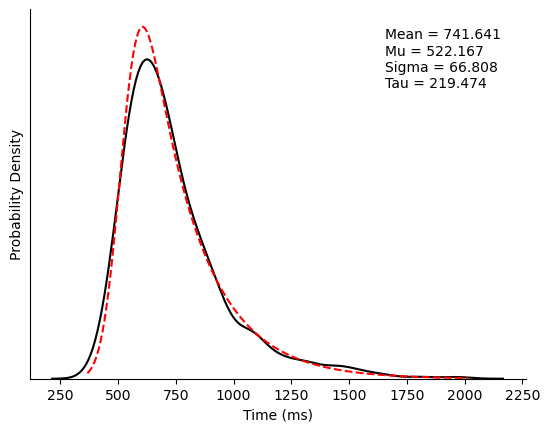

In [ ]:
# Plot our response time data like Balota and Yap (2011) do

# Fit an ex-gaussian function to the data (maximum liklihood estimation)
K, loc, scale = exponnorm.fit(df['rt'])

# exponorm fits an exgaussian function to the data (here our reaction time data)
# It finds the best values for K, loc, and scale
# K = shape parameter. This is the ratio of the exponential tail to the gaussian spread (K = tau/sigma)
# loc = how much the distribution should shift right or left
# scale = sigma (the standard deviation of the gaussian component of the distribution)

# Recover parameters (give them the same names as in Balota & Yap, 2011)
mu    = loc                            # mu is the same as loc
sigma = scale                          # sigma is the same as scale
tau   = K * scale                      # mean of the exponential component
mean = mu + tau                        # the "theoretical" mean of the fitted function
#empmean = df['rt'].mean()             # the "empirical" mean of the data (what "mean" normally, uhh.. means)

# Make a figure like the ones in Balota & Yap (2011). 
ax = sns.kdeplot(data = df, x = 'rt', color = 'black')                                  # plot the data as a distribution
# uncomment the next two lines to check the fit of the function to the data
#x = np.linspace(df['rt'].min(), df['rt'].max(), 200)                                   # datapoint for plotting theoretical exgaussian 
#ax.plot(x, exponnorm.pdf(x, K, loc, scale), color='red', linestyle='--')               # plot theoretical exgauss function on top of acutal data (to check fit)
values = f"Mean = {mean:.3f}\nMu = {mu:.3f}\nSigma = {sigma:.3f}\nTau = {tau:.3f}"      # assemble the text for the legend
ax.text(0.95, 0.95, values,                                                             # x and y coordinates for annotations
        transform=ax.transAxes,                                                         # fixes text box to the figure, not the data
        ha='right', va='top',ma='left',                                                 # position and algin the text in the box
        fontsize=10)                                                                    # I mean, the font size
        #bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))                     # make a box around the annotation, if you want
ax.set(xlabel='Time (ms)', ylabel='Probability Density')                                # Change the axis labels
ax.tick_params(left=False, labelleft=False)                                             # Remove the ticks and values on the y-axis
sns.despine()                                                                           # Remove the top and right boundary lines